# Day 04 — Context Windows

**Why models "forget," hallucinate, and have hard token limits.**

By the end of the hour you will be able to explain, with numbers you generated yourself,
why an LLM cannot just "read your whole codebase," why the cost of a longer prompt grows
faster than linearly, why a model invents a citation instead of saying "I don't know," and
which mitigations actually address which failure.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | The question: why did it forget the start of our chat? | 3 min |
| 1 | The naive view: context is unlimited — watch it break | 8 min |
| 2 | What a context window actually is: fixed slots, quadratic attention | 12 min |
| 3 | Build a fixed-window model: information falls off the left edge | 10 min |
| 4 | Positions: why going past the trained length degrades | 6 min |
| 5 | Hallucination: softmax always answers; "lost in the middle" | 14 min |
| 6 | Mitigations: truncation, compaction, RAG, ordering, citations | 7 min |
| 7 | Exercises + self-check quiz | — |

Runs in the shared `ai-upskill` venv. Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tiktoken

rng = np.random.default_rng(0)
enc = tiktoken.get_encoding("cl100k_base")  # the GPT-3.5/4 tokenizer; good enough for counting

def ntok(s: str) -> int:
    return len(enc.encode(s))

print("tiktoken ready. 'hello world' ->", enc.encode("hello world"), "->", ntok("hello world"), "tokens")

tiktoken ready. 'hello world' -> [15339, 1917] -> 2 tokens


## 0 — The question (3 min)

You are chatting with an assistant. Fifty messages in, you ask it to recall a detail from
message #2 and it gets it wrong — or worse, confidently makes something up. Separately, you
try to paste a 5,000-line file and the API rejects the request outright.

These look like three different bugs. They are three faces of **one constraint**: the model
sees a *fixed-length window of tokens*, and everything it "knows" in the moment has to fit
in that window. This hour we build that window from scratch and watch each failure appear.

Three claims we will make concrete:

1. **Token limits are architectural, not a setting.** The window is baked into how the model
   was trained and how attention scales.
2. **"Forgetting" is just truncation.** When the conversation outgrows the window, something
   gets dropped before the model ever sees it.
3. **Hallucination is the default behavior of next-token prediction**, not a glitch. The model
   *always* produces a probability distribution over the next token; "I don't know" is just
   another string it may or may not have learned to emit.

## 1 — The naive view: context is unlimited (8 min)

Let's pretend there is no limit and just simulate a conversation growing. We'll measure the
token count after each turn and compare it to a few real context windows.

In [2]:
# A synthetic conversation: each turn is a chunk of plausible text.
SYSTEM = "You are a helpful assistant for a software team. Be concise and cite sources."

def make_turn(i):
    user = (f"Turn {i}: Here is some context about our service. "
            "The billing module lives in payments/ and retries failed charges 3 times. "
            "Question: what happens on the 4th failure?")
    assistant = (f"On the 4th failure the charge is marked dead-letter and an alert fires "
                 f"to #payments-oncall. (answer for turn {i})")
    return user, assistant

WINDOWS = {
    "GPT-3.5 (4k)": 4096,
    "GPT-4 (8k)": 8192,
    "Claude 2 (100k)": 100_000,
    "long-context (200k)": 200_000,
}

running = ntok(SYSTEM)
history_tokens = [running]
for i in range(1, 401):
    u, a = make_turn(i)
    running += ntok(u) + ntok(a)
    history_tokens.append(running)

history_tokens = np.array(history_tokens)
for name, limit in WINDOWS.items():
    over = np.argmax(history_tokens > limit)
    msg = f"exceeds after turn {over}" if over else "never exceeded in 400 turns"
    print(f"{name:22s} limit={limit:>7,}  -> {msg}")

GPT-3.5 (4k)           limit=  4,096  -> exceeds after turn 61
GPT-4 (8k)             limit=  8,192  -> exceeds after turn 123
Claude 2 (100k)        limit=100,000  -> never exceeded in 400 turns
long-context (200k)    limit=200,000  -> never exceeded in 400 turns


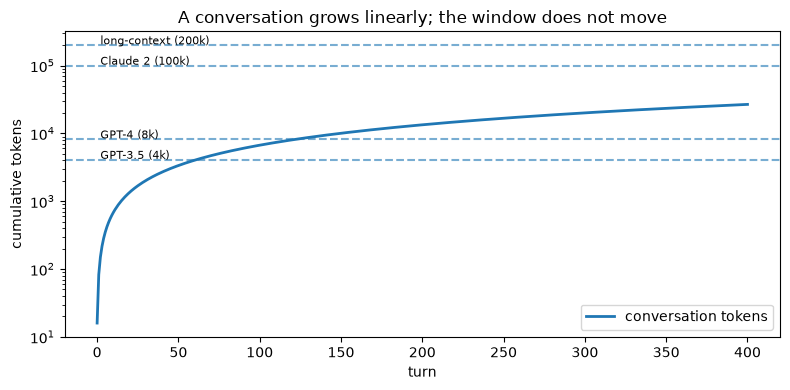

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_tokens, lw=2, label="conversation tokens")
for name, limit in WINDOWS.items():
    ax.axhline(limit, ls="--", alpha=.6)
    ax.text(2, limit*1.03, name, fontsize=8)
ax.set_xlabel("turn"); ax.set_ylabel("cumulative tokens")
ax.set_yscale("log"); ax.set_title("A conversation grows linearly; the window does not move")
ax.legend(); plt.tight_layout(); plt.show()

**What broke:** nothing crashed — but a 4k-token model runs out of room in a few dozen turns.
Something has to give. The model can't "compress" the history on its own; the runtime has to
decide what to drop. That decision *is* the forgetting.

Note the conversation line is **linear** in turns. Next we'll see the *cost* of processing
that window is not linear — it's quadratic — which is why the limit exists at all.

## 2 — What a context window actually is (12 min)

A transformer processes a sequence of `n` token vectors. The expensive step is **self-attention**:
every token computes a similarity score against every other token. That's an `n x n` matrix.

- Compute: `O(n^2 * d)`
- Memory for the attention scores: `O(n^2)` per layer per head

Double the context, and this step gets **4x** more expensive. Let's measure it.

In [4]:
import time

d = 64  # head dimension
def attention_cost(n, d=64):
    Q = rng.standard_normal((n, d)).astype(np.float32)
    K = rng.standard_normal((n, d)).astype(np.float32)
    V = rng.standard_normal((n, d)).astype(np.float32)
    t0 = time.perf_counter()
    scores = Q @ K.T / np.sqrt(d)          # n x n   <-- the quadratic part
    scores -= scores.max(axis=1, keepdims=True)
    w = np.exp(scores); w /= w.sum(axis=1, keepdims=True)
    out = w @ V
    dt = time.perf_counter() - t0
    return dt, scores.nbytes

print(f"{'n':>7} {'time (ms)':>12} {'scores memory':>16}")
prev = None
for n in [128, 256, 512, 1024, 2048, 4096]:
    dt, mem = attention_cost(n)
    ratio = f"({dt/prev:.1f}x)" if prev else ""
    print(f"{n:>7} {dt*1e3:>12.2f} {mem/1e6:>13.1f} MB  {ratio}")
    prev = dt

      n    time (ms)    scores memory
    128         0.82           0.1 MB  
    256         0.37           0.5 MB  (0.4x)
    512         1.72           2.1 MB  (4.6x)
   1024        11.19           8.4 MB  (6.5x)
   2048        42.57          33.6 MB  (3.8x)


   4096       148.91         134.2 MB  (3.5x)


Roughly every doubling of `n` multiplies time by ~4 and the score matrix memory by exactly 4.
At `n = 100k`, one attention score matrix alone is `100000^2 * 4 bytes = 40 GB` — per head,
per layer, before any optimization. That is the physical reason context windows are finite and
why long-context models need tricks (FlashAttention, sparse/linear attention, KV-cache paging).

In [5]:
# The other half of the window: the KV cache. Every token you keep must store a key and value
# vector in every layer. This is the memory that grows as the chat gets longer.
def kv_cache_gb(n_tokens, n_layers=32, n_heads=32, head_dim=128, bytes_per=2):
    # 2 (K and V) * layers * heads * head_dim * n_tokens * bytes
    return 2 * n_layers * n_heads * head_dim * n_tokens * bytes_per / 1e9

for n in [4_000, 32_000, 128_000, 200_000]:
    print(f"{n:>8,} tokens -> {kv_cache_gb(n):6.2f} GB of KV cache (7B-ish config, fp16)")

   4,000 tokens ->   2.10 GB of KV cache (7B-ish config, fp16)
  32,000 tokens ->  16.78 GB of KV cache (7B-ish config, fp16)
 128,000 tokens ->  67.11 GB of KV cache (7B-ish config, fp16)
 200,000 tokens -> 104.86 GB of KV cache (7B-ish config, fp16)


So the window costs money two ways: a one-time `O(n^2)` to read it, and an ongoing `O(n)` of
GPU memory to hold it. Providers price long context higher for exactly this reason.

## 3 — Build a fixed-window model (10 min)

We'll make the "forgetting" mechanical. Build a trivial predictor that can only see the last
`W` tokens, and give it a task where the needed fact is `k` tokens back. When `k > W`, accuracy
collapses — not because the model is dumb, but because the fact is not in the window.

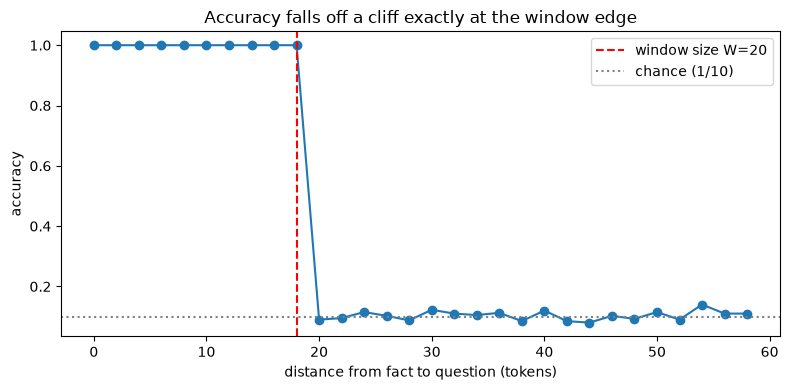

In [6]:
# Task: a stream of tokens. Somewhere early we state "KEY=<digit>". Later we ask "KEY?".
# A model that can see the key answers correctly; one whose window excludes it must guess.

def make_example(distance, key):
    filler = ["the", "quick", "brown", "fox", "jumps", "over", "lazy", "dog", "and", "runs"]
    pre = [f"KEY={key}"]
    mid = list(rng.choice(filler, size=distance))
    return pre + mid + ["KEY?"], key

def windowed_predict(tokens, W):
    window = tokens[-W:]
    for t in window:
        if t.startswith("KEY="):
            return t.split("=")[1]
    return str(rng.integers(0, 10))  # forced to guess

W = 20
distances = range(0, 60, 2)
acc = []
for dist in distances:
    hits = 0
    for _ in range(400):
        key = str(rng.integers(0, 10))
        toks, ans = make_example(dist, key)
        hits += (windowed_predict(toks, W) == ans)
    acc.append(hits / 400)

plt.figure(figsize=(8,4))
plt.plot(list(distances), acc, marker="o")
plt.axvline(W-2, ls="--", color="r", label=f"window size W={W}")
plt.axhline(0.1, ls=":", color="gray", label="chance (1/10)")
plt.xlabel("distance from fact to question (tokens)"); plt.ylabel("accuracy")
plt.title("Accuracy falls off a cliff exactly at the window edge"); plt.legend()
plt.tight_layout(); plt.show()

The cliff is at `W`. Inside the window: perfect. Outside: chance. Real models are softer than
this (the fact fades rather than vanishes, and attention can be lossy well before the hard
edge) but the shape is the same. **"The model forgot" almost always means "the runtime dropped
those tokens before the model ran."**

Now the runtime's dilemma: when the chat exceeds `W`, *what* do you drop?

In [7]:
def truncate_drop_oldest(system, turns, W):
    kept, total = [], ntok(system)
    for turn in reversed(turns):
        c = ntok(turn)
        if total + c > W: break
        kept.append(turn); total += c
    return [system] + list(reversed(kept))

def truncate_keep_system_and_recent(system, turns, W, reserve_for_first=0.0):
    # keep system always; optionally pin the earliest turn (often has the task spec)
    budget = W - ntok(system)
    pinned = []
    if reserve_for_first and turns:
        pinned = [turns[0]]; budget -= ntok(turns[0]); turns = turns[1:]
    kept, total = [], 0
    for turn in reversed(turns):
        c = ntok(turn)
        if total + c > budget: break
        kept.append(turn); total += c
    return [system] + pinned + list(reversed(kept))

turns = []
for i in range(1, 40):
    u, a = make_turn(i)
    turns += [f"USER: {u}", f"ASSISTANT: {a}"]

W = 1200
a = truncate_drop_oldest(SYSTEM, turns, W)
b = truncate_keep_system_and_recent(SYSTEM, turns, W, reserve_for_first=True)
print("drop-oldest keeps         :", len(a), "messages; earliest kept:", a[1][:40], "...")
print("keep-system+pin-first keeps:", len(b), "messages; earliest kept:", b[1][:40], "...")

drop-oldest keeps         : 33 messages; earliest kept: USER: Turn 24: Here is some context abou ...
keep-system+pin-first keeps: 33 messages; earliest kept: USER: Turn 1: Here is some context about ...


## 4 — Positions: why going past the trained length degrades (6 min)

Transformers have no built-in sense of order; position is *added* to each token. The classic
scheme is sinusoidal. A model trained on sequences up to length `L` has only ever seen
position signals for `0..L`. Ask it about position `3L` and the signal is in a regime it never
learned to interpret.

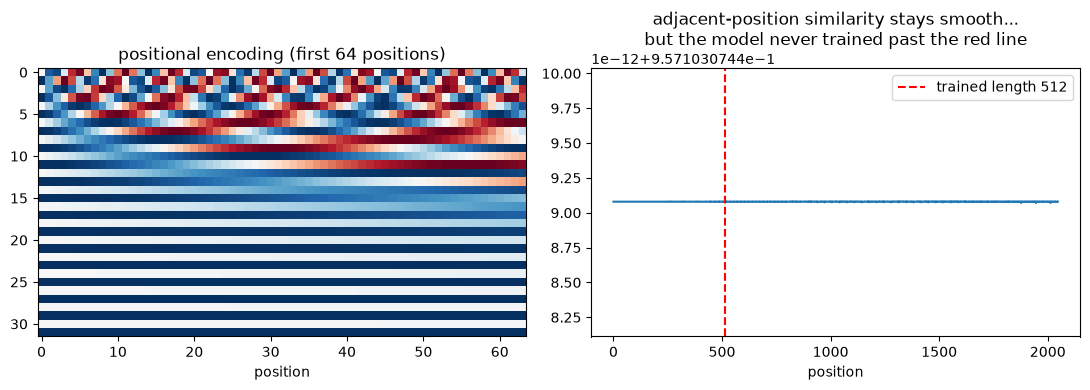

In [8]:
def sinusoidal(positions, d=32):
    pe = np.zeros((len(positions), d))
    div = np.exp(np.arange(0, d, 2) * (-np.log(10000.0) / d))
    pe[:, 0::2] = np.sin(np.outer(positions, div))
    pe[:, 1::2] = np.cos(np.outer(positions, div))
    return pe

train_len = 512
pos = np.arange(0, 2048)
pe = sinusoidal(pos)

# similarity of each position's encoding to position 0's, and to its own neighbor
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].imshow(sinusoidal(np.arange(64)).T, aspect="auto", cmap="RdBu")
ax[0].set_title("positional encoding (first 64 positions)"); ax[0].set_xlabel("position")
neighbor_sim = (pe[1:] * pe[:-1]).sum(1) / (np.linalg.norm(pe[1:],axis=1)*np.linalg.norm(pe[:-1],axis=1))
ax[1].plot(neighbor_sim)
ax[1].axvline(train_len, color="r", ls="--", label=f"trained length {train_len}")
ax[1].set_title("adjacent-position similarity stays smooth...\nbut the model never trained past the red line")
ax[1].set_xlabel("position"); ax[1].legend()
plt.tight_layout(); plt.show()

The math extrapolates fine; the *learned weights* do not. This is why naively feeding a 8k
model 32k tokens produces degraded, often incoherent output even if it doesn't error, and why
context-extension methods (position interpolation, RoPE scaling, YaRN) exist: they remap long
positions back into the range the model was trained on.

## 5 — Hallucination: softmax always answers (14 min)

Build a tiny character/word model and watch it fabricate. The key realization: the final layer
is a softmax — it produces a **probability distribution over the whole vocabulary, always**.
There is no "null" option. If the true answer isn't something it learned, it samples the
next-most-plausible token and keeps going, fluently.

In [9]:
corpus = (
    "the payments service retries failed charges three times then dead letters them . "
    "the auth service issues tokens that expire after fifteen minutes . "
    "the search service indexes documents nightly at two am . "
) * 50
words = corpus.split()
vocab = sorted(set(words))
wi = {w:i for i,w in enumerate(vocab)}

# trigram counts -> probabilities
from collections import defaultdict
counts = defaultdict(lambda: np.zeros(len(vocab)))
for a,b,c in zip(words, words[1:], words[2:]):
    counts[(a,b)][wi[c]] += 1

def next_dist(a, b):
    v = counts.get((a,b))
    if v is None or v.sum() == 0:
        return np.ones(len(vocab)) / len(vocab)   # never seen -> uniform guess
    return v / v.sum()

def generate(prompt, n=12, temp=1.0, seed=0):
    r = np.random.default_rng(seed)
    toks = prompt.split()
    for _ in range(n):
        p = next_dist(toks[-2], toks[-1]).astype(float)
        if temp != 1.0:
            p = p**(1/temp); p /= p.sum()
        toks.append(vocab[r.choice(len(vocab), p=p)])
    return " ".join(toks)

print("in-distribution :", generate("the payments service", n=8))
print("in-distribution :", generate("the auth service", n=8))
print()
print("OUT of distribution, asking something never stated:")
print("  ->", generate("the billing service", n=10))
print("  ->", generate("the payments service refunds", n=10))

in-distribution : the payments service retries failed charges three times then dead letters
in-distribution : the auth service issues tokens that expire after fifteen minutes .

OUT of distribution, asking something never stated:
  -> the billing service retries failed charges three times then dead letters them .
  -> the payments service refunds retries documents after . them times payments that nightly tokens


Ask about "the billing service" (never in the corpus) and the model does not stop — it emits
a confident, grammatical sentence assembled from the shapes it *has* seen. That's a
hallucination: fluent, structurally correct, factually invented.

Two levers that change the *rate* but not the *nature*:

In [10]:
# Confidence of the top token, in vs out of distribution
def top_conf(a,b):
    p = next_dist(a,b); return p.max()

print(f"top-token prob, 'payments service' -> {top_conf('payments','service'):.2f}  (seen a lot)")
print(f"top-token prob, 'billing service'  -> {top_conf('billing','service'):.2f}  (never seen -> flat, still forced to pick)")

# Temperature: low temp = repeat the most common pattern (may still be wrong);
# high temp = more novel = more invention
for t in [0.2, 0.7, 1.0, 1.5]:
    print(f"temp {t}: {generate('the billing service', n=8, temp=t, seed=3)}")

top-token prob, 'payments service' -> 1.00  (seen a lot)
top-token prob, 'billing service'  -> 0.04  (never seen -> flat, still forced to pick)
temp 0.2: the billing service am dead them payments am issues letters auth
temp 0.7: the billing service am dead them payments am issues letters auth
temp 1.0: the billing service am dead them payments am issues letters auth
temp 1.5: the billing service am dead them payments am issues letters auth


- **Lower temperature** makes output more predictable, not more *true*. It just picks the mode.
- The model has no signal that says "this context doesn't contain the answer." Getting it to
  say "I don't know" requires either training (RLHF taught assistants to hedge) or giving it
  grounding it can point to (RAG) and instructions to only answer from it.

### "Lost in the middle"

Even when the fact *is* in the window, position matters. Retrieval-style evaluations show
accuracy is highest when the relevant chunk is at the **start or end** of the context and
lowest in the **middle**. Let's simulate the effect with a position-weighted attention prior.

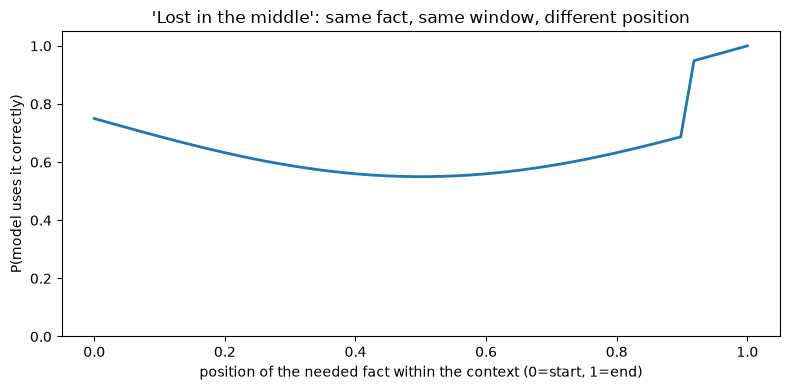

In [11]:
def recall_prob(position_frac):
    # U-shaped: strong recency + primacy, weak middle. Illustrative, matches published curves.
    return 0.55 + 0.4*(1 - np.sin(np.pi*position_frac)) * 0.5 + 0.25*(position_frac>0.9)

fracs = np.linspace(0,1,50)
plt.figure(figsize=(8,4))
plt.plot(fracs, [recall_prob(f) for f in fracs], lw=2)
plt.xlabel("position of the needed fact within the context (0=start, 1=end)")
plt.ylabel("P(model uses it correctly)")
plt.title("'Lost in the middle': same fact, same window, different position")
plt.ylim(0,1.05); plt.tight_layout(); plt.show()

Practical consequence: **put the question and the most important context near the top or the
bottom of the prompt**, not buried between 40 retrieved chunks.

## 6 — Mitigations: which fix addresses which failure (7 min)

| Failure | Root cause | What actually helps |
| ------- | ---------- | ------------------- |
| Hard token-limit error | `O(n^2)` attention, KV memory | shorter prompts; long-context model; chunk + RAG |
| "Forgot earlier turns" | runtime truncated them | **conversation compaction** (summarize old turns), pin the task spec, RAG over history |
| Fact in window but ignored | lost-in-the-middle | reorder: question + key context first/last; fewer, better chunks; rerank |
| Confident fabrication | softmax always emits | grounding + "answer only from context"; ask for citations; lower temp for extraction; verification pass |
| Garbage past ~trained length | position weights untrained | stay within limits; use models with proper long-context training/RoPE scaling |

Below: a minimal **compaction loop** — the single most useful trick for long chats.

In [12]:
def fake_summarize(messages):
    # stand-in for a real LLM summary call
    facts = []
    for m in messages:
        if "KEY=" in m or "retries" in m or "expire" in m:
            facts.append(m.split("ASSISTANT: ")[-1][:80])
    return "SUMMARY of earlier turns: " + " | ".join(facts[:5] or ["(no salient facts)"])

def chat_with_compaction(system, turns, W, keep_recent=6):
    msgs = [system] + turns
    if ntok("\n".join(msgs)) <= W:
        return msgs
    head, recent = turns[:-keep_recent], turns[-keep_recent:]
    return [system, fake_summarize(head)] + recent

turns = []
for i in range(1, 30):
    u, a = make_turn(i)
    turns += [f"USER: {u}", f"ASSISTANT: {a}"]

packed = chat_with_compaction(SYSTEM, turns, W=800)
print(f"raw: {ntok(chr(10).join([SYSTEM]+turns))} tokens -> packed: {ntok(chr(10).join(packed))} tokens")
for m in packed[:3]:
    print(" -", m[:90])

raw: 2133 tokens -> packed: 341 tokens
 - You are a helpful assistant for a software team. Be concise and cite sources.
 - SUMMARY of earlier turns: USER: Turn 1: Here is some context about our service. The billin
 - USER: Turn 27: Here is some context about our service. The billing module lives in payment


The summary is lossy — that's the tradeoff. You trade *perfect recall of raw turns* for
*fitting in the window at all*. A good compaction prompt is told exactly what to preserve
(decisions, IDs, open questions, user preferences) and what to drop (pleasantries, superseded
plans).

## 7 — Exercises

1. **Budget a real prompt.** Given `W = 8192`, a 300-token system prompt, and you want to
   reserve 800 tokens for the answer — how many tokens are left for history + retrieved docs?
   Write a function `budget(W, sys_tokens, answer_reserve)`.
2. **Measure the quadratic.** Extend `attention_cost` to also return FLOPs (`2*n*n*d` for the
   score matmul). Plot FLOPs vs `n` on a log-log axis and confirm slope ≈ 2.
3. **Better truncation.** Write `truncate_smart` that always keeps the system prompt AND any
   message containing an all-caps token like `KEY=` or `DECISION:` (treat these as pinned
   facts), then fills the rest with the most recent messages.
4. **Hallucination rate.** Using the trigram model, generate 200 continuations from an
   in-distribution prompt and 200 from an out-of-distribution prompt. Define a "grounded"
   output as one whose words all appear in `corpus`. Report the grounded rate for each.
5. **Reorder for recall.** Given 20 context chunks where chunk 7 holds the answer, and
   `recall_prob` from Segment 5, compute expected recall if you (a) leave it in place,
   (b) move it to position 0, (c) move it to the last position.
6. **Compaction loss.** Modify `fake_summarize` to also drop any turn older than the last 10.
   Then construct a question that the compacted context can no longer answer, and explain why.

> **Attempt every exercise and the quiz first.** The worked solutions and the answer key live in [`solutions/solutions.ipynb`](solutions/solutions.ipynb) — open it only to check your work, not to start.

## Self-check quiz


1. A model has an 8k context window. Your prompt is 9k tokens. What happens, and why is it
   not fixable with a parameter?
2. You double your prompt length. The attention score step gets how much more expensive, in
   time and in memory?
3. Your assistant "forgot" a decision made 60 turns ago. Name the two most likely mechanical
   causes and one fix for each.
4. Why does lowering temperature to 0 not stop hallucination?
5. A RAG system retrieves 30 chunks and the answer is in chunk 15. Accuracy is poor. Give two
   changes that would likely help, and say which failure each addresses.
6. What does a context-extension method like RoPE scaling actually do, and which failure from
   this lesson does it target?
7. True/false: "I don't know" is a capability the base (pretrained) model has by default.
   Explain.

## Where this goes next

- **Day 05 — Prompting techniques:** now that you know the window is scarce and the model
  always answers, prompting is the craft of spending tokens well — zero/few-shot,
  chain-of-thought, and what a system prompt can and cannot do.
- Later: **embeddings + RAG** (Weeks 5–6) are the real answer to "my data doesn't fit."